In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.head()


,name,host_since,host_response_time,host_acceptance_rate,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,accommodates,bathrooms,...,price_q,occupancy_rate,log_reviews,recent_activity,operating_days,log_revenue,room_capacity,neighbourhood_top10,host_since_dt,property_regulation_type
0,Lg Rm in Historic Prospect Heights,2009-12-11,no_reponse_data,no_request,Prospect Heights,Brooklyn,Private room in rental unit,Private room,1,1.0,...,Q3,0.000000,2.302585,0,5564.0,0.000000,3.0,Other,2009-12-11,Residential_long_term
1,"1 Bedroom & your own Bathroom, Elevator Apartment",2010-07-04,no_reponse_data,100%,East Harlem,Manhattan,Private room in condo,Private room,2,1.0,...,Q1,0.000000,4.634729,0,5632.0,0.000000,3.0,Other,2010-07-04,Residential_long_term
2,Luxury Brownstone in Boerum Hill,2010-07-13,within a few hours,40%,Boerum Hill,Brooklyn,Private room in home,Private room,2,2.5,...,Q4,0.000000,3.784190,0,4988.0,0.000000,12.5,Other,2010-07-13,Residential_short_term
3,“Work-from-home” from OUR home.,2010-07-16,within an hour,100%,Williamsburg,Brooklyn,Private room in rental unit,Private room,2,1.0,...,Q2,0.421918,5.616771,0,5695.0,9.904537,3.0,Williamsburg,2010-07-16,Residential_short_term
4,1 br in a 2 br apt (Midtown West),2010-07-17,no_reponse_data,no_request,Hell's Kitchen,Manhattan,Private room in rental unit,Private room,2,0.0,...,Q2,0.000000,3.806662,0,5666.0,0.000000,2.0,Hell's Kitchen,2010-07-17,Residential_long_term


In [9]:
df.shape

(19861, 60)

# 리뷰 / 평점과 성과 분석
- 성과는 가격뿐만 아니라 리뷰와 평점 같은 신뢰 지표의 영향을 받을 가능성;리뷰, 평점은 고객 만족도의 지표로 리뷰가 많거나 평점이 높으면 예약이 더 많이 발생할 것


- 리뷰와 평점이 점유율 및 매출과 어떤 관계가 있을까?


# <가설1 리뷰, 평점이 높을수록 숙소의 점유율이 높을 것이다>

### 평점과 점유율

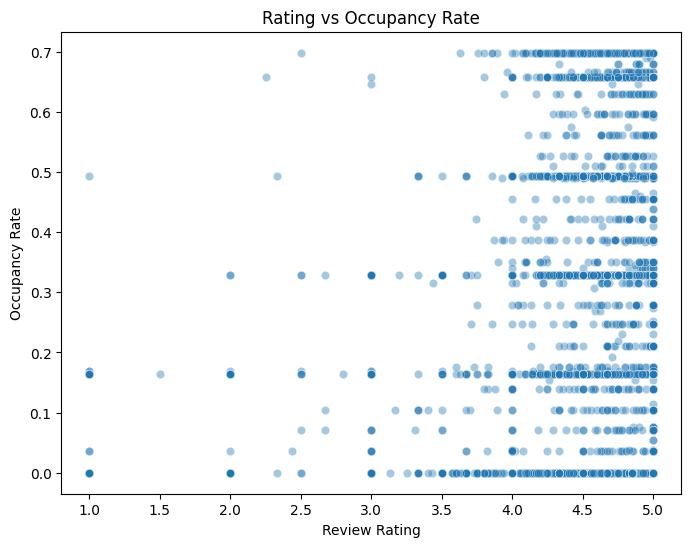

In [10]:
# 평점과 점유율\
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x="review_scores_rating",
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.title("Rating vs Occupancy Rate")
plt.xlabel("Review Rating")
plt.ylabel("Occupancy Rate")

plt.show()

- 대부분의 숙소 평점이 4.0 ~ 5.0 구간에 집중
- 평점이 높은 숙소에서도 점유율이 매우 낮은 사례가 꽤 존재
- 점유율 0에 가까운 숙소가 평점이 높은 구간에서도 많이 존재하여 평점만으로 숙소의 예약 성과를 설명하기는 어려운 듯

=> 평점이 성과에 일부 영향은 줄 수 있으나 주요 원인은 아님 / 가격, 위치, 유형 등 다른 요인 영향

<평점과 점유율 상관관계확인 히트맵>

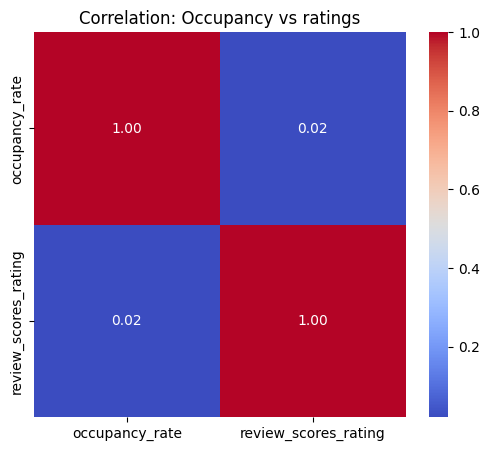

In [53]:
# 상관계수 
correlation = df[['occupancy_rate', 'review_scores_rating']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Occupancy vs ratings')
plt.show()

### 리뷰수와 점유율

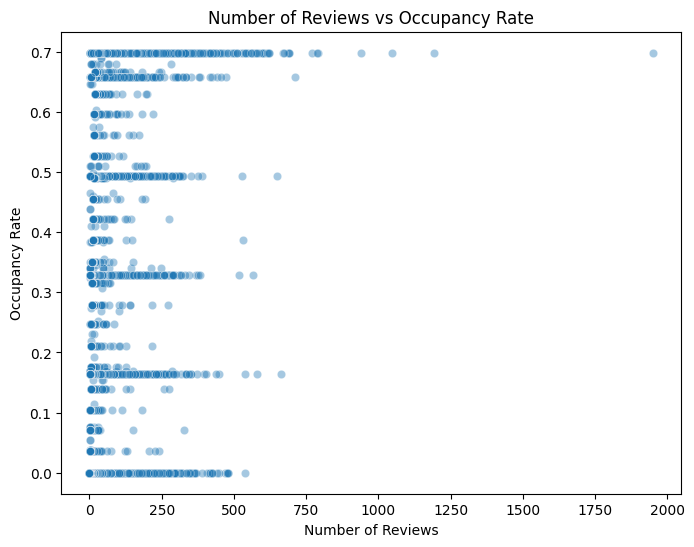

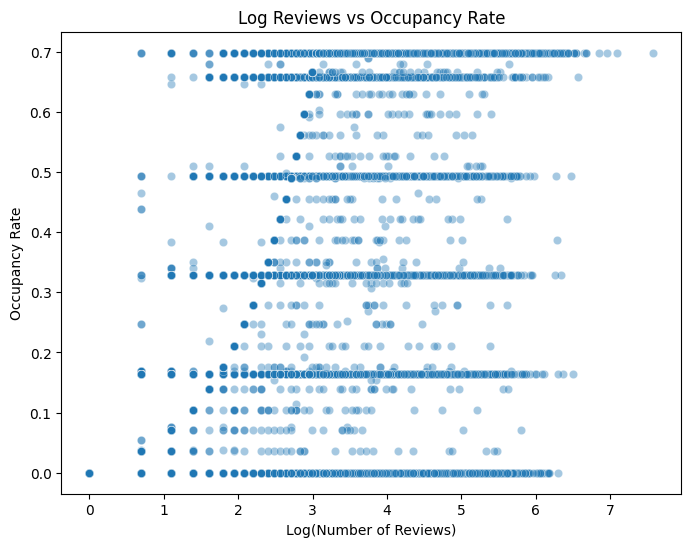

In [14]:
# 리뷰수와 점유율
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="number_of_reviews",
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.title("Number of Reviews vs Occupancy Rate")
plt.xlabel("Number of Reviews")
plt.ylabel("Occupancy Rate")

plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=np.log1p(df["number_of_reviews"]),
    y="occupancy_rate",
    data=df,
    alpha=0.4
)

plt.xlabel("Log(Number of Reviews)")
plt.ylabel("Occupancy Rate")
plt.title("Log Reviews vs Occupancy Rate")

plt.show()

- 리뷰가 많다고 해서 반드시 점유가 압도적으로 높은게 아님
- 로그 변환을 했어도 이터가 특정 수치에 뭉쳐 있음, 특정 점유율 구간들에서 줄지어 있음 
- 특정 예약 비중이 발생하는 패턴이 있다?
- 리뷰값이 0~2여도 점유가 0.7까지 된다는건 리뷰 없어도(신규숙소) 점유할 수 있다는 뜻

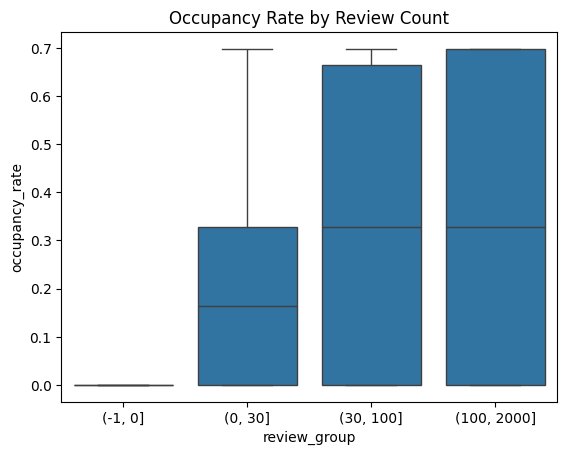

In [37]:
bins = [-1, 0, 30, 100, 2000] # 0이 많아서 경계 겹침, 임의로 구간 나눔-> 0개, 초기, 성장, 인기 숙소

df["review_group"] = pd.cut(df["number_of_reviews"], bins=bins)

sns.boxplot(
    x="review_group",
    y="occupancy_rate",
    data=df
)

plt.title("Occupancy Rate by Review Count")
plt.show()

- 확실히 리뷰 많을 수록 점유율 높음

상관관계 확인

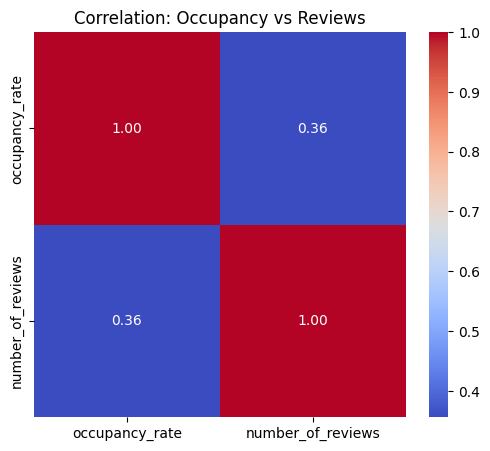

In [22]:
# 상관계수 
correlation = df[['occupancy_rate', 'number_of_reviews']].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation: Occupancy vs Reviews')
plt.show()

- 상관계수 0.36 -> 약하지만 유의미한 관계
- 리뷰가 많을수록 예약률이 높아지는 경향이 있긴 하지만, 리뷰 수만으로  완벽하게 설명할 수는 없음 마찬가지로 가격, 위치 등 다른 영향 있을 듯

# <가설2 리뷰 수가 적을수록 매출이 0인 비율이 높다?>

### 리뷰 수가 적은 숙소 → 매출 0 비율 확인

In [ ]:
bins = [-1, 0, 30, 100, 2000] # 0이 많아서 경계 겹침, 임의로 구간 나눔-> 0개, 초기, 성장, 인기 숙소

df["review_group"] = pd.cut(df["number_of_reviews"], bins=bins)

df["zero_revenue"] = (df["estimated_revenue_l365d"] == 0).astype(int)

df.groupby("review_group")["zero_revenue"].mean()


review_group
(-1, 0]        1.000000
(0, 30]        0.413122
(30, 100]      0.357620
(100, 2000]    0.299604
Name: zero_revenue, dtype: float64

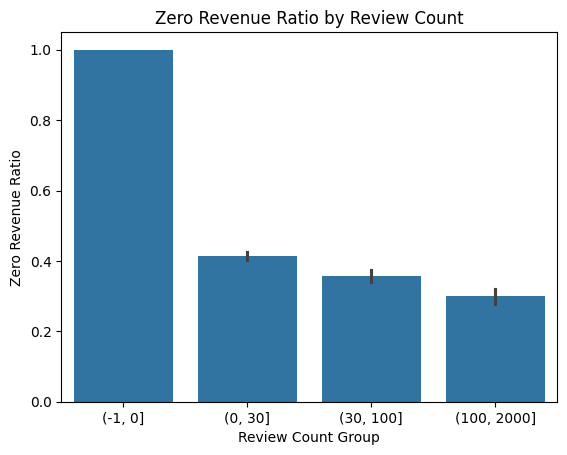

In [42]:
sns.barplot(
    x="review_group",
    y="zero_revenue",
    data=df
)

plt.title("Zero Revenue Ratio by Review Count")
plt.ylabel("Zero Revenue Ratio")
plt.xlabel("Review Count Group")

plt.show()

- 리뷰 0개 숙소 매출 0 비율이 1.0으로 100% 매출 없음
- 차례로 매출 0 비율이 100%, 약 41%, 35%, 30%
- 리뷰가 증가하면 매출이 없는 숙소의 비율이 감소하는 한다는건 리뷰수가 숙소의 수요와 인기도를 말함

## 근데 운영을 오래했으면 당연히 리뷰수가 많은 것 아님? (리뷰수가 많은 이유는 운영기간 때문일 수도 있으니까) 
## 리뷰가 쌓일 수 있었던 실질적인? 기간
## 즉, 숙소가 첫 리뷰 이후 얼마나 운영됐는지를 계산 해보자 해서 'first_review'로 'operating_days' 파생

<Axes: xlabel='operating_days', ylabel='number_of_reviews'>

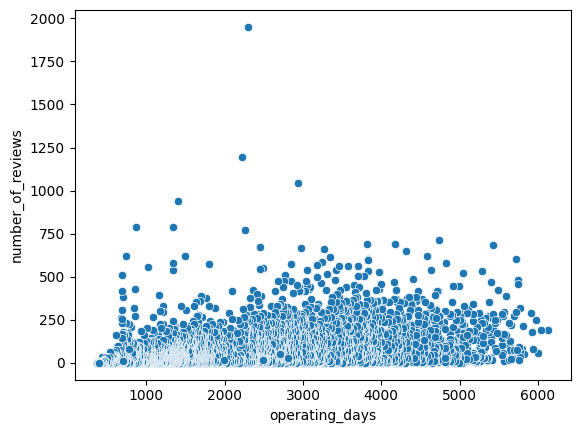

In [ ]:
df["first_review"] = pd.to_datetime(df["first_review"])

# 운영 기간 계산
df["operating_days"] = (
    pd.Timestamp("today") - df["first_review"]
).dt.days

sns.scatterplot(
    x="operating_days",
    y="number_of_reviews",
    data=df
)

그래프 별로다

6519


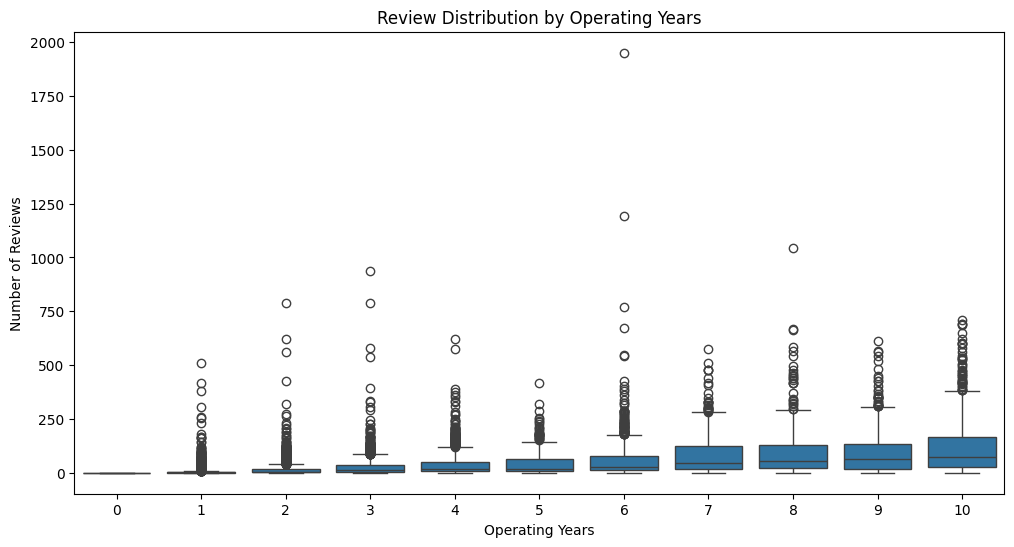

In [51]:
print(df['operating_days'].isna().sum())
df['operating_years'] = (df['operating_days'] // 365).fillna(0).astype(int)

# 10년 이상은 하나로 
df.loc[df['operating_years'] > 10, 'operating_years'] = 10


plt.figure(figsize=(12, 6))
sns.boxplot(x='operating_years', y='number_of_reviews', data=df)
plt.title("Review Distribution by Operating Years")
plt.xlabel("Operating Years")
plt.ylabel("Number of Reviews")
plt.show()

- 운영기간 길수록 중간값 높아짐 => 오래 운영하면 리뷰가 쌓인다는 것 확안
- 운영기간 뒤로갈 ㅅ수록 IQR이 길어짐 => 오래 운영한다고 리뷰 많이 받는다는게 아니고 격차가 벌어진다는 뜻
- 3년치, 6년차, 8년차 상단 이상치 -> 운영기간 상관 없이 특수한 경우가 있음
- 운영오래하면 리뷰 누적되는거 맞는데 같은 연차여도 축적에는 차이가 있다
- 그리고 위에서 리뷰 없으면 매출이 0이었으니가 초기에 리뷰를 확보하는게 에어비앤비 시장에서의 생존 핵심 중 하나임